mkdir -p failed for path /dfs/user/sttruong/.cache/matplotlib: [Errno 13] Permission denied: '/dfs/user/sttruong'
Matplotlib created a temporary cache directory at /tmp/user/21130/matplotlib-1bh9lrjv because there was an issue with the default path (/dfs/user/sttruong/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


(91, 5493)
missing percentage: 0.0039350782114299316


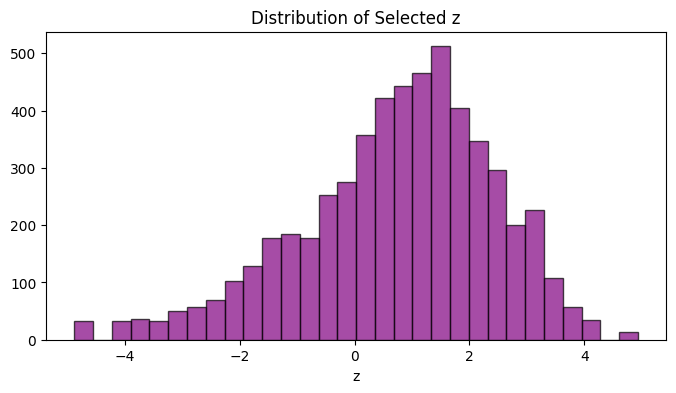

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
from tueplots import bundles
bundles.icml2024()
import sys
sys.path.append("..")
from utils import visualize_response_matrix

benchmark = "lite"
# scenario = "gsm"
# scenario = "mmlu"

with open(f"../data/gather_helm_data/results_with_z.pkl", "rb") as f:
    results = pickle.load(f)
results = results.loc[:, results.columns.get_level_values("benchmark") == benchmark]
results = results[~results.isna().all(axis=1)]

output_dir = "../result/gather_helm_data"
visualize_response_matrix(results, results, f"{output_dir}/response_matrix_{benchmark}.png")
print(results.shape)
print(f"missing percentage: {results.isna().values.sum() / (results.shape[0] * results.shape[1])}")

z_array = results.columns.get_level_values("z").astype(float).to_numpy()
sorted_indices = np.argsort(z_array)
df = results.iloc[:, sorted_indices]
col_names = [f"{i+1}" for i in range(len(z_array))]

new_columns = []
for col, col_name in zip(df.columns, col_names):
    new_columns.append(col + (col_name,))
df.columns = pd.MultiIndex.from_tuples(new_columns, names=["request.prompt", "references", "scenario", "benchmark", "z", "col_names"])
    
colname_to_z = {}
for col in df.columns:
    z = col[-2]
    col_name = col[-1]
    colname_to_z[col_name] = z
with open(f"colname2z_{benchmark}_all.json", "w") as f:
    json.dump(colname_to_z, f, indent=4)

# write the item content to a txt
with open(f"item_content_{benchmark}_all.txt", "w") as f:
    for col in df.columns:
        prompt = col[0]
        ref = col[1]
        z = col[-2]
        col_name = col[-1]
        f.write(f"###{col_name}, difficulty: {z}\n###prompt: {prompt}\n###reference: {ref}\n\n\n\n\n")

# save response matrix to csv
df.columns = df.columns.get_level_values("col_names")
# df.index.name = None
df.to_csv(f"resmat_{benchmark}_all.csv", index=True)

# Plot selected z distribution
plt.figure(figsize=(8, 4))
plt.hist(z_array, bins=30, alpha=0.7, color='purple', edgecolor='black')
plt.title("Distribution of Selected z")
plt.xlabel("z")
plt.savefig(f"z_distri_{benchmark}_all.png", dpi=300, bbox_inches='tight')